In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


Data Cleaning

In [6]:
# Drop the column which have maximum null value
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# Rename the column name
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [9]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [10]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [11]:
df['target']=encoder.fit_transform(df['target'])

In [12]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [13]:
# Check duplicate value in ouur data sets
df.duplicated().sum()

np.int64(403)

In [14]:
df=df.drop_duplicates()

In [15]:
df.shape

(5169, 2)

EDA

In [16]:
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

[]

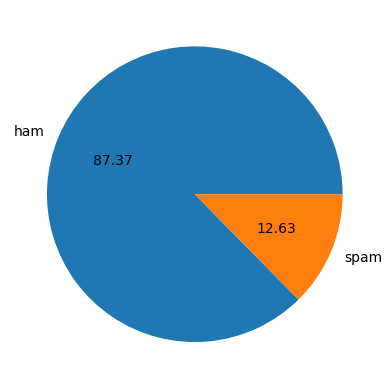

In [17]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.plot()

In [18]:
# data is imbalnced

In [19]:
import nltk

In [20]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
df['num_characters']=df['text'].apply(len)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7828\399031894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_characters']=df['text'].apply(len)


In [22]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
# for fetch the word we use nltk
# num of word
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7828\1613374706.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [25]:
# tokanize on the basis of no of sentence
df['num_sentances']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7828\1554153936.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_sentances']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [26]:
df.head()

,target,text,num_characters,num_words,num_sentances
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df.describe()

,target,num_characters,num_words,num_sentances
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [28]:
#Analyze the ham msg
df[df['target']==0][['num_characters','num_words','num_sentances']].describe()

,num_characters,num_words,num_sentances
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [679]:
#Analyze the spam msg
df[df['target']==1][['num_characters','num_words','num_sentances']].describe()

,num_characters,num_words,num_sentances
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [29]:
import seaborn as sns 


[]

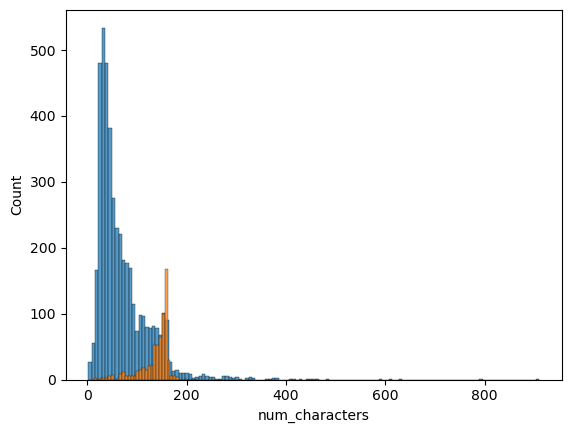

In [30]:
plt.Figure(figsize=(6,14))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'])
plt.plot()

[]

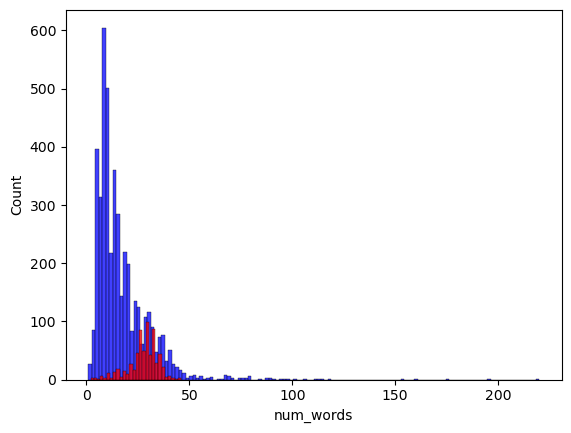

In [31]:
# On the word
plt.Figure(figsize=(6,14))
sns.histplot(df[df['target']==0]['num_words'],color='blue')
sns.histplot(df[df['target']==1]['num_words'],color='red')
plt.plot()

[]

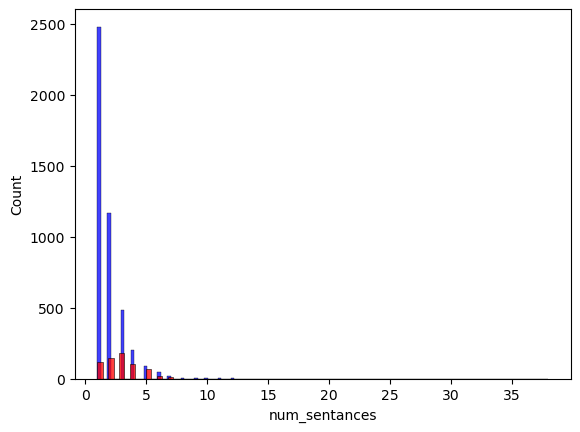

In [683]:
# On the Sentence
plt.Figure(figsize=(6,14))
sns.histplot(df[df['target']==0]['num_sentances'],color='blue')
sns.histplot(df[df['target']==1]['num_sentances'],color='red')
plt.plot()

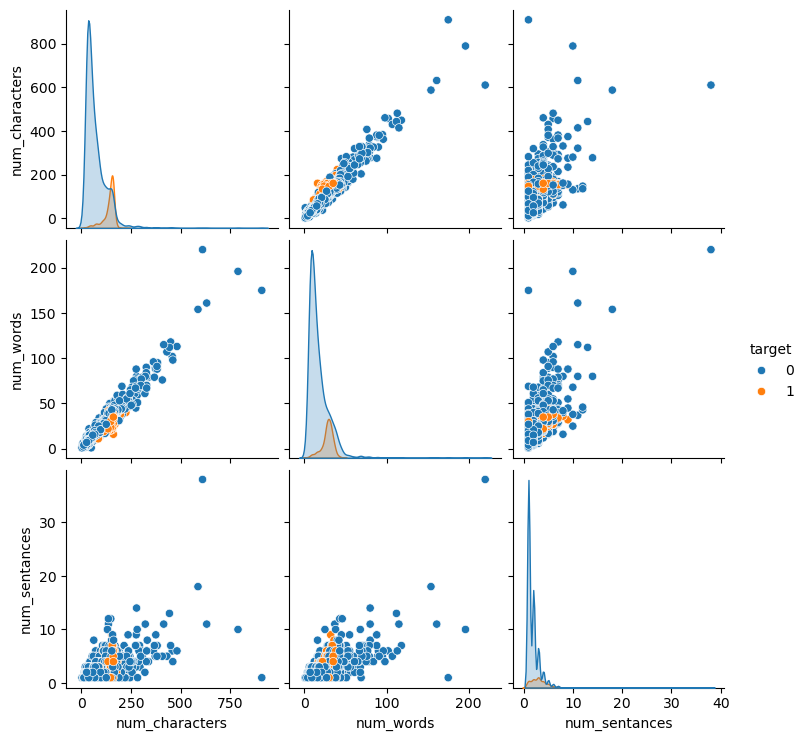

In [32]:
sns.pairplot(df,hue='target')
plt.show()

<Axes: >

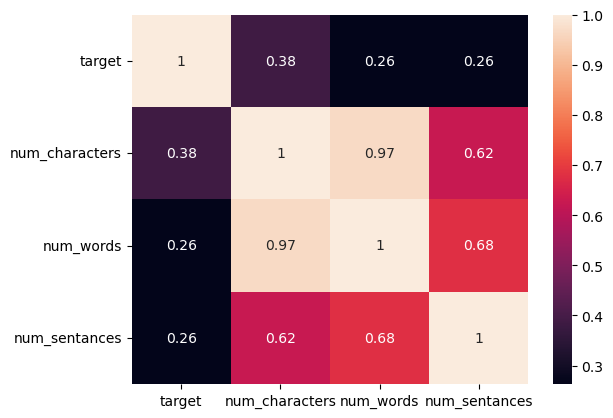

In [33]:
sns.heatmap(df[['target','num_characters','num_words','num_sentances']].corr(),annot=True)

Data/Text Preprocessing

In [34]:
# Lower case
# Tokenization
# Removing Special Character
# Removing stop words and punctuation
# Stemming

Now we create a function which perform the all five above operation which need for Text Preprocessing

In [35]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [36]:
from nltk.corpus import stopwords

stop_words=stopwords.words('english')


In [37]:

from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [38]:
def transform_text(text):
    text=text.lower()# convert in lower case
    text=nltk.word_tokenize(text) #for tokanization
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()

    for i in text:
        if i not in stop_words and i not in string.punctuation:
            y.append(i)
    # Streaming
    text=y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)


In [39]:
df['transformed_text']=df['text'].apply(transform_text)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7828\4139466366.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transformed_text']=df['text'].apply(transform_text)


Word cloud

In [40]:
# A WordCloud is a visualization that shows the most frequently occurring words in your text.
from  wordcloud import WordCloud

check for spam messages

In [41]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [42]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

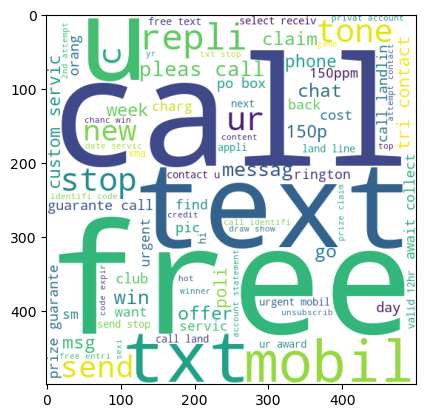

In [43]:
plt.imshow(spam_wc)

Now, for ham messages

In [44]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

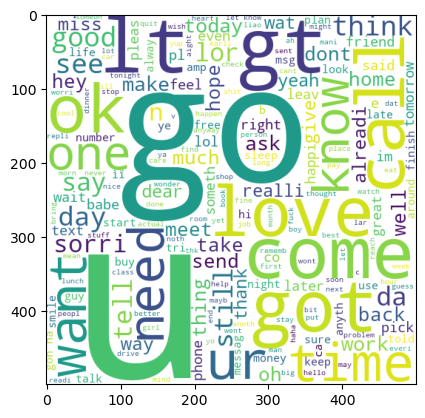

In [45]:
plt.imshow(ham_wc)

Now check top 30 word which used in both of them spam and in ham

In Spam Top 30 word

In [46]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [47]:
len(spam_corpus)

9939

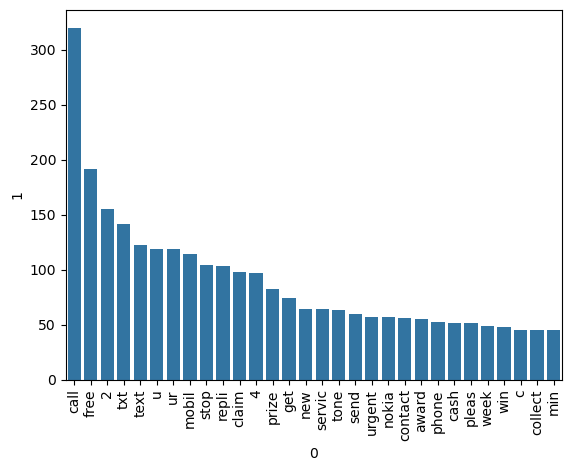

In [48]:
from collections import Counter

df_common = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=df_common[0], y=df_common[1])

plt.xticks(rotation='vertical')
plt.show()

In ham top 30 word

In [49]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [50]:
len(ham_corpus)

35404

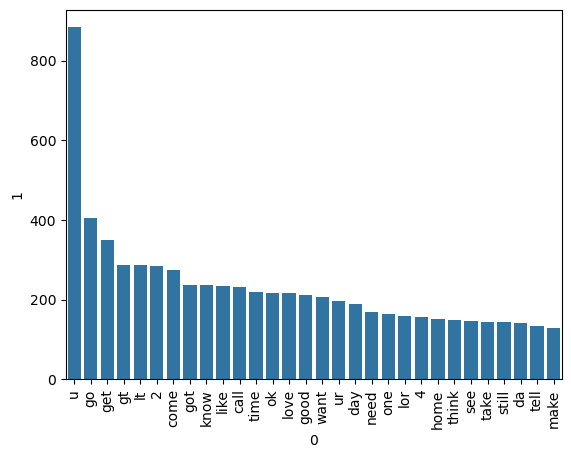

In [51]:
from collections import Counter

df_common = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=df_common[0], y=df_common[1])

plt.xticks(rotation='vertical')
plt.show()

In [52]:
df.head()

,target,text,num_characters,num_words,num_sentances,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


Model Building


In [53]:
# We use CountVectorizer and TF-IDF to convert text into numbers, because ML models cannot directly understand raw text.
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv=CountVectorizer()
tf=TfidfVectorizer(max_features=3000)

In [54]:
# x=cv.fit_transform(df['transformed_text']).toarray()
x=tf.fit_transform(df['transformed_text']).toarray()

In [707]:
# x.shape

In [55]:
y=df['target'].values


In [56]:
from sklearn.model_selection import train_test_split


In [57]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [58]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,precision_score, f1_score, confusion_matrix

In [59]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [713]:
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred1))
print("confusion_matrix:",confusion_matrix(y_test,y_pred1))
print("precision_score:",precision_score(y_test,y_pred1))

Accuracy: 0.8762088974854932
confusion_matrix: [[793 103]
 [ 25 113]]
precision_score: 0.5231481481481481


In [60]:
mnb.fit(x_train,y_train)
y_pred2=mnb.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred2))
print("confusion_matrix:",confusion_matrix(y_test,y_pred2))
print("precision_score:",precision_score(y_test,y_pred2))

Accuracy: 0.9709864603481625
confusion_matrix: [[896   0]
 [ 30 108]]
precision_score: 1.0


In [715]:
bnb.fit(x_train,y_train)
y_pred3=bnb.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred3))
print("confusion_matrix:",confusion_matrix(y_test,y_pred3))
print("precision_score:",precision_score(y_test,y_pred3))

Accuracy: 0.9700193423597679
confusion_matrix: [[893   3]
 [ 28 110]]
precision_score: 0.9734513274336283


In [716]:
# tfidf with mnib give better precision score

Now check almost all ML model

In [717]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [718]:
lr=LogisticRegression(solver='liblinear',penalty='l1')
svc=SVC(kernel='sigmoid',gamma=1.0)
mnb=MultinomialNB()
dt=DecisionTreeClassifier(max_depth=5)
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
knn=KNeighborsClassifier()
adb=AdaBoostClassifier(n_estimators=50,random_state=2)
bgc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbc=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier()

In [719]:
clfs={
    'LR':lr,
    'SVC':svc,
    'MNB':mnb,
    'DT':dt,
    'RFC':rfc,
    'KNN':knn,
    'ADB':adb,
    "BGC":bgc,
    'ETC':etc,
    'GBC':gbc,
    'XGB':xgb
}

In [720]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)

    return accuracy,precision

In [721]:
accuracy_scores=[]
precision_scores=[]

for name,clf in clfs.items():
    current_acc,curr_precision=train_classifier(clf,x_train,y_train,x_test,y_test)

    print("For: ",name)
    print("Accuracy: ",current_acc)
    print("Precision: ",curr_precision)

    accuracy_scores.append(current_acc)
    precision_scores.append(curr_precision)


For:  LR
Accuracy:  0.9516441005802708
Precision:  0.94
For:  SVC
Accuracy:  0.9729206963249516
Precision:  0.9741379310344828
For:  MNB
Accuracy:  0.9593810444874274
Precision:  1.0
For:  DT
Accuracy:  0.9342359767891683
Precision:  0.8301886792452831
For:  RFC
Accuracy:  0.971953578336557
Precision:  1.0
For:  KNN
Accuracy:  0.9003868471953579
Precision:  1.0
For:  ADB
Accuracy:  0.9245647969052224
Precision:  0.8409090909090909
For:  BGC
Accuracy:  0.9584139264990329
Precision:  0.8625954198473282
For:  ETC
Accuracy:  0.9729206963249516
Precision:  0.9824561403508771
For:  GBC
Accuracy:  0.9526112185686654
Precision:  0.9238095238095239
For:  XGB
Accuracy:  0.9709864603481625
Precision:  0.9285714285714286


In [729]:
performance_df=pd.DataFrame({"Algorithm":clfs.keys(),"Accuracy":accuracy_scores,"Precision":precision_scores}).sort_values('Precision',ascending=False)

In [730]:
performance_df

,Algorithm,Accuracy,Precision
2,MNB,0.959381,1.000000
4,RFC,0.971954,1.000000
5,KNN,0.900387,1.000000
8,ETC,0.972921,0.982456
1,SVC,0.972921,0.974138
0,LR,0.951644,0.940000
10,XGB,0.970986,0.928571
9,GBC,0.952611,0.923810
7,BGC,0.958414,0.862595
6,ADB,0.924565,0.840909


In [733]:
# So finally we decide that, we should apply MNB, bcz it is better to other but when i work on the comapny and make a website for a client then , we will also apply different different paramater and ml algo like voting ensemble, stacking to improvw more the value of accuracy but preserve the value of precision bcz it is 1

In [61]:
import pickle
pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))